# 02. Machine Learning - Real Estate Price Prediction
**Real Estate Market Intelligence Dashboard**

This notebook focuses on training and validating a machine learning pipeline to predict listing prices based on geographic, physical, and market indicators. We compare multiple models, tune hyperparameters, and export a production-ready model pipeline.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

### 1. Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/cleaned_properties.csv")
# Split features and target
# Target is listing price (Price_USD)
features = ['City', 'Property_Type', 'Area_SqFt', 'Bedrooms', 'Bathrooms', 'Property_Age', 'Demand_Score', 'Customer_Rating']
target = 'Price_USD'

X = df[features]
y = df[target]

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (3491, 8), y shape: (3491,)


### 2. Preprocessing & Feature Engineering Pipeline

In [3]:
# Define columns categories
categorical_cols = ['City', 'Property_Type']
numeric_cols = ['Area_SqFt', 'Bedrooms', 'Bathrooms', 'Property_Age', 'Demand_Score', 'Customer_Rating']

# Create ColumnTransformer to scale numeric and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

### 3. Split Dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 2792, Test size: 699


### 4. Train and Compare Regression Models

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    # Create complete ML pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Fit model
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'pipeline': pipeline, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"=== {name} ===")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R2:   {r2:.4f}\n")

=== Linear Regression ===
MAE:  $2,299,365.24
RMSE: $3,792,148.47
R2:   0.6917



=== Random Forest ===
MAE:  $1,139,005.24
RMSE: $2,401,342.34
R2:   0.8764



=== Gradient Boosting ===
MAE:  $1,179,161.19
RMSE: $2,409,619.05
R2:   0.8755



### 5. Tuning Best Model (Random Forest Hyperparameter Tuning)

In [6]:
# Hyperparameter tuning for Random Forest using Grid Search
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
    ])

param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

print("Tuning Random Forest Regressor...")
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='r2', verbose=1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
best_r2 = grid_search.best_score_

print(f"Best CV R2 Score: {best_r2:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Tuning Random Forest Regressor...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


Best CV R2 Score: 0.8761
Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}


### 6. Evaluate Tuned Model

In [7]:
# Final evaluations on the Holdout Test Set
y_pred = best_pipeline.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"Final Model Metrics on Holdout Test Set:")
print(f"  - Mean Absolute Error (MAE): ${final_mae:,.2f}")
print(f"  - Root Mean Squared Error (RMSE): ${final_rmse:,.2f}")
print(f"  - R-squared (R2): {final_r2:.4f}")

Final Model Metrics on Holdout Test Set:
  - Mean Absolute Error (MAE): $1,139,513.50
  - Root Mean Squared Error (RMSE): $2,388,433.44
  - R-squared (R2): 0.8777


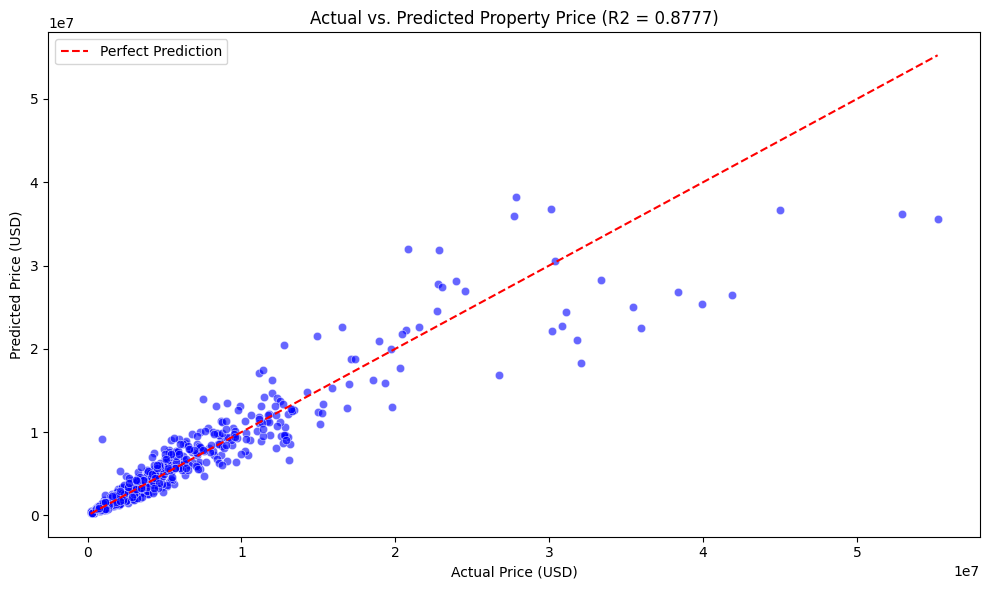

In [8]:
# Scatter plot of actual vs predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
# Plot ideal line
ideal_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', label='Perfect Prediction')
plt.title(f'Actual vs. Predicted Property Price (R2 = {final_r2:.4f})')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/model_performance.png', dpi=300)
plt.show()

### 7. Export Model Pipeline

In [9]:
model_export_path = "../models/price_predictor.joblib"
os.makedirs("../models", exist_ok=True)

# Export model alongside feature columns list
model_package = {
    'model': best_pipeline,
    'features': features,
    'val_r2': final_r2
}

joblib.dump(model_package, model_export_path)
print(f"Saved final trained ML Pipeline to: {model_export_path}")

Saved final trained ML Pipeline to: ../models/price_predictor.joblib
